In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class GraphSchema(TypedDict):
    values: list
    name: str
    result: str

In [3]:
def process_values(state):
    values = state['values']
    values_sum = 0
    for value in values:
        values_sum += value
    state['result'] = f"Here is the sum of values for you {state['name']}: {values_sum}"

    return state


In [4]:
multi_ip_graph = StateGraph(GraphSchema)
multi_ip_graph.add_node('SumNode', process_values)
multi_ip_graph.add_edge(START, 'SumNode')
multi_ip_graph.add_edge('SumNode', END)

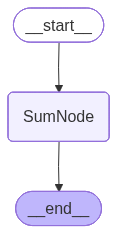

In [6]:
multi_ip_graph_compiled = multi_ip_graph.compile()
multi_ip_graph_compiled

In [7]:
multi_ip_graph_compiled.invoke(
    {
        'values': [1,2,3,4,5],
        'name': 'Adib',
        'result': ''
    }
)

{'values': [1, 2, 3, 4, 5],
 'name': 'Adib',
 'result': 'Here is the sum of values for you Adib: 15'}